In [1]:
%load_ext autoreload
%autoreload 2

import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import xgcm
import matplotlib.pyplot as plt
import xbudget

from xhistogram.xarray import histogram

from load_example_ecco_grid import *
from eccov4r4_budget_diagnostics import *
from xbudget.llc90 import *
import xeos

print("xarray:", xr.__version__)
print("xgcm:", xgcm.__version__)

/Users/anthonymeza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/xeos/eos.py:1: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


xarray: 2026.4.0
xgcm: 0.9.0


In [2]:
def calc_uv_bolus(ds, grid, allow_rechunk=True):
    psix = ds["GM_PsiX"].where(np.isfinite(ds["GM_PsiX"]), 0.0)
    psiy = ds["GM_PsiY"].where(np.isfinite(ds["GM_PsiY"]), 0.0)

    psix_u = psix * ds["dyG"]
    psiy_v = psiy * ds["dxG"]

    UBOL_TRSP = grid.diff(psix_u.chunk({"k_l": -1}), "Z", boundary="fill")
    VBOL_TRSP = grid.diff(psiy_v.chunk({"k_l": -1}), "Z", boundary="fill")

    psi_diff = diff_2d_flux_llc90(
        grid,
        psix_u.unify_chunks(),
        psiy_v.unify_chunks(),
        allow_rechunk=allow_rechunk,
    )

    WBOL_TRSP = psi_diff["X"] + psi_diff["Y"]

    UBOL_TRSP = UBOL_TRSP.where(ds["maskW"]).fillna(0.0)
    VBOL_TRSP = VBOL_TRSP.where(ds["maskS"]).fillna(0.0)
    WBOL_TRSP = WBOL_TRSP.fillna(0.0)

    UVELSTAR = UBOL_TRSP / (ds["drF"] * ds["dyG"])
    VVELSTAR = VBOL_TRSP / (ds["drF"] * ds["dxG"])
    WVELSTAR = WBOL_TRSP / ds["rA"]

    return xr.Dataset(
        {
            "UVELSTAR": UVELSTAR.rename("UVELSTAR"),
            "VVELSTAR": VVELSTAR.rename("VVELSTAR"),
            "WVELSTAR": WVELSTAR.rename("WVELSTAR"),
        }
    )

In [3]:
def remap_transport(ds, trsp, coord_name, grid, coord_edges, method="histogram"):
    coord_edges = np.asarray(coord_edges)
    coord_centers = 0.5 * (coord_edges[:-1] + coord_edges[1:])

    if "i_g" in trsp.dims:
        face_axis = "X"
        mask = ds["maskW"]
    elif "j_g" in trsp.dims:
        face_axis = "Y"
        mask = ds["maskS"]
    else:
        raise ValueError("Expected transport on `i_g` or `j_g`.")

    coord_face = grid.interp(
        ds[coord_name].chunk({"tile": -1, "i": -1, "j": -1, "k": -1}),
        face_axis,
    )

    coord_face = coord_face.where(mask)
    trsp = trsp.where(mask).fillna(0.0)

    if method == "histogram":
        trsp_remapped = histogram(coord_face, bins=[coord_edges], weights=trsp, dim=["k"])
        trsp_remapped = trsp_remapped.rename({f"{coord_name}_bin": coord_name})
        trsp_remapped = trsp_remapped.assign_coords({coord_name: coord_centers})
        return trsp_remapped

    if method == "conservative":
        coord_face_p1 = grid.interp(
            coord_face.chunk({"k": -1}),
            "Z", to="outer", boundary="extend")

        trsp_remapped = grid.transform(
            trsp.chunk({"k": -1}),
            axis="Z",
            target=coord_edges,
            target_data=coord_face_p1.chunk({"k_p1": -1}),
            method="conservative")

        if "remapped" in trsp_remapped.dims:
            trsp_remapped = trsp_remapped.rename({"remapped": coord_name})

        trsp_remapped = trsp_remapped.assign_coords({coord_name: coord_centers})
        return trsp_remapped

    raise ValueError("method must be either 'histogram' or 'conservative'")


def remap_transports(
    ds,
    grid,
    URES_TRSP,
    VRES_TRSP,
    coord_edges,
    coord_name="SIG2",
    method="histogram",
):
    remap_func = lambda uv_trsp: remap_transport(ds, uv_trsp, coord_name, 
                                        grid, coord_edges, method=method)
    U_remapped = remap_func(URES_TRSP)
    V_remapped = remap_func(VRES_TRSP)

    return U_remapped, V_remapped


def calc_psi_from_remapped_transports(
    ds,
    grid,
    U_remapped,
    V_remapped,
    coord_name="SIG2",
    allow_rechunk=True,
):
    diff_UV_RES = diff_2d_flux_llc90(
        grid,
        U_remapped.fillna(0.0),
        V_remapped.fillna(0.0),
        allow_rechunk=allow_rechunk,
    )

    UVRES_CONV = -(diff_UV_RES["X"].fillna(0.0) + diff_UV_RES["Y"].fillna(0.0))
    UVRES_CONV = UVRES_CONV.mean("time").compute()

    lat_vals = np.arange(-88, 88)

    lats_da = xr.DataArray(
        lat_vals,
        coords={"lat": lat_vals},
        dims=("lat",),
    )

    psi = xr.zeros_like(UVRES_CONV[coord_name] * lats_da)
    psi.coords[coord_name] = UVRES_CONV[coord_name]

    def reverse_cumsum(da, dim):
        return da.isel({dim: slice(None, None, -1)}).cumsum(dim).isel({dim: slice(None, None, -1)})

    for lat in lat_vals:
        latmask = ds["YC"] < lat
        masked_conv = (UVRES_CONV * latmask).sum(["tile", "i", "j"])

        psi.loc[{"lat": lat}] = reverse_cumsum(masked_conv, coord_name).compute()

    return 1e-6 * psi

In [4]:
def get_trsp(ds, vel):
    if "i_g" in vel.dims:
        trsp = vel.fillna(0.0) * ds["drF"] * ds["dyG"]
        return trsp.where(ds["maskW"]).fillna(0.0)

    if "j_g" in vel.dims:
        trsp = vel.fillna(0.0) * ds["drF"] * ds["dxG"]
        return trsp.where(ds["maskS"]).fillna(0.0)

    if "k_l" in vel.dims:
        trsp = vel.fillna(0.0) * ds["rA"]
        return trsp.fillna(0.0)

    raise ValueError("Expected velocity on `i_g`, `j_g`, or `k_l`.")

In [5]:
transport_ds_path = "../../example-ECCOV4r4-budget-terms/data/ECCO_transport_terms.zarr"

ds = xr.open_mfdataset(
    transport_ds_path,
    parallel=True,
    engine="zarr",
).isel(time=slice(0, 12))

grid = construct_grid(ds)

bolus_velocities = calc_uv_bolus(ds, grid, allow_rechunk=True)

# remove the "bad bolus"
ds = ds.drop_vars(["UVELSTAR", "VVELSTAR", "WVELSTAR"])
ds = xr.merge([ds, bolus_velocities])

URES_TRSP = get_trsp(ds, ds["UVELMASS"] + ds["UVELSTAR"])
VRES_TRSP = get_trsp(ds, ds["VVELMASS"] + ds["VVELSTAR"])

/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/Users/anthonymeza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/xarray/structure/chunks.py:183: PerformanceWarning: Increasing number of chunks by factor of 20
  _, chunked_data = chunkmanager.unify_chunks(*unify_chunks_args)
/var/folders/vt/sjvxnnwn7y51hx1c814wrxn80000gn/T/ipykernel_29066/3906410143.py:15: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds

In [6]:
ds["SIG2"] = xeos.rho(ds["THETA"].where(ds["hFacC"] > 0.0),
             ds["SALT"].where(ds["hFacC"] > 0.0),
             2000,
             "JMD-95")

ds["SIG2"] -= 1000

sigma2_target = np.hstack(
    [
        np.arange(0, 30, 5),
        np.arange(30, 35, 0.25),
        np.arange(35, 37, 0.025),
        np.arange(37, 37.2, 0.01),
        38,
        40,
    ])


Ures_SIG2_hist, Vres_SIG2_hist = remap_transports(
    ds,
    grid,
    URES_TRSP,
    VRES_TRSP,
    sigma2_target,
    coord_name="SIG2",
    method="histogram")

psi_hist = calc_psi_from_remapped_transports(
    ds,
    grid,
    Ures_SIG2_hist,
    Vres_SIG2_hist,
    coord_name="SIG2",
    allow_rechunk=True)

Ures_SIG2_cons, Vres_SIG2_cons = remap_transports(
    ds,
    grid,
    URES_TRSP,
    VRES_TRSP,
    sigma2_target,
    coord_name="SIG2",
    method="conservative")

psi_cons = calc_psi_from_remapped_transports(
    ds,
    grid,
    Ures_SIG2_cons,
    Vres_SIG2_cons,
    coord_name="SIG2",
    allow_rechunk=True)

/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/Users/anthonymeza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/xarray/structure/chunks.py:183: PerformanceWarning: Increasing number of chunks by factor of 20
  _, chunked_data = chunkmanager.unify_chunks(*unify_chunks_args)
/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/Users/anthonymeza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/xarray/structure/chunks.py:183: PerformanceWarning: Increasing number of chunks by facto

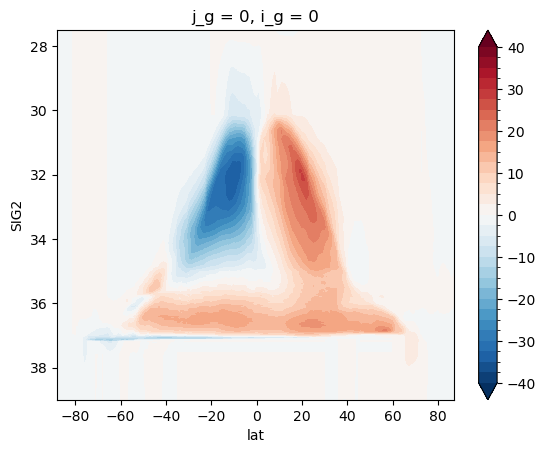

In [7]:
levels = np.arange(-40, 40 + 0.1, 2.5)
psi_hist.sel(SIG2 = slice(27, None)).plot.contourf(x = "lat", y = "SIG2", levels = levels, extend = "both", yincrease = False)

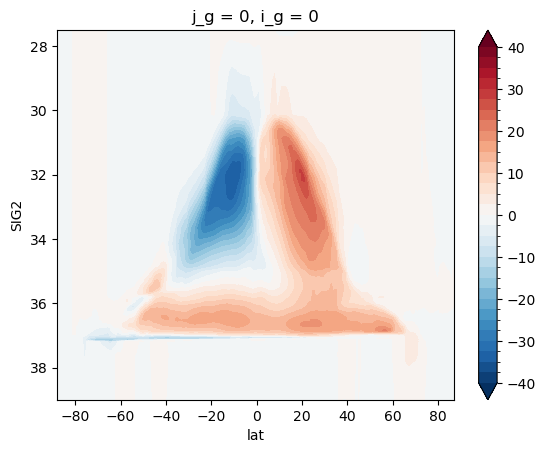

In [8]:
levels = np.arange(-40, 40 + 0.1, 2.5)
psi_cons.sel(SIG2 = slice(27, None)).plot.contourf(x = "lat", y = "SIG2", levels = levels, extend = "both", yincrease = False)